In [1]:
# package import
import math
import pandas as pd

# read file from folder
data = pd.read_sas('/Users/mtjen/Desktop/schiltz24/nhanes_project/interview/nhanes_int.sas7bdat')
data = data.drop('low_chol', axis = 1)
data.head()

,SEQN,age,high_chol,total_chol,has_hype_med,sex,ethnicity,is_diabetic,does_smoke,sbp,dbp,has_hbp,ethnicity_binary
0,62164.0,44.0,28.0,190.0,0.0,b'Female',b'Non-Hispanic White',0.0,0.0,118.000000,60.000000,0.0,b'Other'
1,62172.0,43.0,73.0,169.0,0.0,b'Female',b'Non-Hispanic Black',0.0,1.0,102.000000,71.333333,0.0,b'Black'
2,62177.0,51.0,43.0,198.0,0.0,b'Male',b'Non-Hispanic Asian',0.0,1.0,146.666667,70.000000,0.0,b'Other'
3,62179.0,55.0,54.0,206.0,0.0,b'Male',b'Non-Hispanic Asian',0.0,0.0,124.666667,76.000000,0.0,b'Other'
4,62191.0,70.0,35.0,118.0,0.0,b'Male',b'Non-Hispanic Black',0.0,0.0,158.666667,62.666667,0.0,b'Black'


In [2]:
##################################################
##########
##########
########## Cleaning/Processing
##########
##########
##################################################

In [3]:
# convert variables of type byte string to string

data['sex'] = data['sex'].str.decode('utf-8')
data['ethnicity'] = data['ethnicity'].str.decode('utf-8')
data['ethnicity_binary'] = data['ethnicity_binary'].str.decode('utf-8')
data.head()

,SEQN,age,high_chol,total_chol,has_hype_med,sex,ethnicity,is_diabetic,does_smoke,sbp,dbp,has_hbp,ethnicity_binary
0,62164.0,44.0,28.0,190.0,0.0,Female,Non-Hispanic White,0.0,0.0,118.000000,60.000000,0.0,Other
1,62172.0,43.0,73.0,169.0,0.0,Female,Non-Hispanic Black,0.0,1.0,102.000000,71.333333,0.0,Black
2,62177.0,51.0,43.0,198.0,0.0,Male,Non-Hispanic Asian,0.0,1.0,146.666667,70.000000,0.0,Other
3,62179.0,55.0,54.0,206.0,0.0,Male,Non-Hispanic Asian,0.0,0.0,124.666667,76.000000,0.0,Other
4,62191.0,70.0,35.0,118.0,0.0,Male,Non-Hispanic Black,0.0,0.0,158.666667,62.666667,0.0,Black


In [4]:
data.dtypes

SEQN                float64
age                 float64
high_chol           float64
total_chol          float64
has_hype_med        float64
sex                  object
ethnicity            object
is_diabetic         float64
does_smoke          float64
sbp                 float64
dbp                 float64
has_hbp             float64
ethnicity_binary     object
dtype: object

In [5]:
# change data types
data['SEQN'] = data['SEQN'].astype(int)
data['age'] = data['age'].astype(int)
data['high_chol'] = data['high_chol'].astype(int)
data['total_chol'] = data['total_chol'].astype(int)
data['has_hype_med'] = data['has_hype_med'].astype(int)
data['is_diabetic'] = data['is_diabetic'].astype(int)
data['does_smoke'] = data['does_smoke'].astype(int)
data['has_hbp'] = data['has_hbp'].astype(int)

data.dtypes

SEQN                  int64
age                   int64
high_chol             int64
total_chol            int64
has_hype_med          int64
sex                  object
ethnicity            object
is_diabetic           int64
does_smoke            int64
sbp                 float64
dbp                 float64
has_hbp               int64
ethnicity_binary     object
dtype: object

In [6]:
# calculate risk scores

risk_scores = []
group_one_flags = []
group_two_flags = []
sex_eth_group = []

# iterate through rows
for index in range(0, data.shape[0]):
    # initialize flags to 0
    g1_flag = 0
    g2_flag = 0
    
    # row values
    sex_val = data['sex'][index]
    ethnicity_binary_val = data['ethnicity_binary'][index]
    age_val = data['age'][index]
    high_chol_val = data['high_chol'][index]
    total_chol_val = data['total_chol'][index]
    has_hype_med_val = data['has_hype_med'][index]
    sbp_val = data['sbp'][index]
    is_diabetic_val = data['is_diabetic'][index]
    does_smoke_val = data['does_smoke'][index]
    
    # ethnicity = other
    if ethnicity_binary_val == 'Other':
        if sex_val == 'Female':
            ln_risk = (-29.799 * math.log(age_val) - 
                       13.578 * math.log(high_chol_val) + 
                       13.54 * math.log(total_chol_val) + 
                       4.884 * math.log(age_val)**2 - 3.114 * math.log(age_val) * math.log(total_chol_val) + 
                       3.149 * math.log(age_val) * math.log(high_chol_val) + 
                       2.019 * (has_hype_med_val) * math.log(sbp_val) +
                       1.957 * (1 - has_hype_med_val) * math.log(sbp_val) +
                       0.661 * is_diabetic_val + 7.5740 * does_smoke_val + 
                       -1.665 * does_smoke_val * math.log(age_val))
            risk_score = 1 - 0.9665 ** math.exp(ln_risk + 29.1817)
            group = 'Other Female'
        # other males
        else:
            ln_risk = (12.344 * math.log(age_val) + 
                       -7.990 * math.log(high_chol_val) + 
                       11.853 * math.log(total_chol_val) +
                       1.797 * (has_hype_med_val) * math.log(sbp_val) + 
                       1.764 * (1 - has_hype_med_val) * math.log(sbp_val) +
                       0.658 * is_diabetic_val + 
                       7.837 * does_smoke_val +
                       1.769 * math.log(age_val) * math.log(high_chol_val) + 
                       -2.664 * math.log(age_val) * math.log(total_chol_val) +
                       -1.795 * does_smoke_val * math.log(age_val))
            risk_score = 1 - 0.9144 ** math.exp(ln_risk - 61.18)
            group = 'Other Male'
            
    # ethnicity = black
    else:
        if sex_val == 'Female':
            ln_risk = (17.1141 * math.log(age_val) + 
                        -18.9196 * math.log(high_chol_val) + 
                        0.9396 * math.log(total_chol_val) + 
                        4.4748 * math.log(age_val) * math.log(high_chol_val) + 
                        29.2907 * has_hype_med_val * math.log(sbp_val) + 
                        27.8197 * (1 - has_hype_med_val) * math.log(sbp_val) +
                        -6.4321 * has_hype_med_val * math.log(sbp_val) * math.log(age_val) +
                        -6.0873 * (1 - has_hype_med_val) * math.log(sbp_val) * math.log(age_val) +
                        0.8738 * is_diabetic_val + 
                        0.6908 * does_smoke_val)
            risk_score = 1 - 0.95334 ** math.exp(ln_risk - 86.6081)
            group = 'Black Female'
        # black males
        else:
            ln_risk = (2.469 * math.log(age_val) + 
                        -0.307 * math.log(high_chol_val) + 
                        0.302 * math.log(total_chol_val) + 
                        1.916 * has_hype_med_val * math.log(sbp_val) + 
                        1.809 * (1 - has_hype_med_val) * math.log(sbp_val) +
                        0.645 * is_diabetic_val + 
                        0.549 * does_smoke_val)
            risk_score = 1 - 0.8954 ** math.exp(ln_risk - 19.54)
            group = 'Black Male'
    
    
    risk_scores.append(risk_score)
    sex_eth_group.append(group)
    
    # see if risk score passes threshold levels
    if risk_score >= 0.075:
        g1_flag = 1
        
        if risk_score >= 0.100:
            g2_flag = 1
            
    group_one_flags.append(g1_flag)
    group_two_flags.append(g2_flag)
    
    
# add variable to dataframe
data['risk_score'] = risk_scores
data['g1_is_rec'] = group_one_flags
data['g2_is_rec'] = group_two_flags
data['group'] = sex_eth_group
data.head()

,SEQN,age,high_chol,total_chol,has_hype_med,sex,ethnicity,is_diabetic,does_smoke,sbp,dbp,has_hbp,ethnicity_binary,risk_score,g1_is_rec,g2_is_rec,group
0,62164,44,28,190,0,Female,Non-Hispanic White,0,0,118.000000,60.000000,0,Other,0.017973,0,0,Other Female
1,62172,43,73,169,0,Female,Non-Hispanic Black,0,1,102.000000,71.333333,0,Black,0.002583,0,0,Black Female
2,62177,51,43,198,0,Male,Non-Hispanic Asian,0,1,146.666667,70.000000,0,Other,0.117270,1,1,Other Male
3,62179,55,54,206,0,Male,Non-Hispanic Asian,0,0,124.666667,76.000000,0,Other,0.051719,0,0,Other Male
4,62191,70,35,118,0,Male,Non-Hispanic Black,0,0,158.666667,62.666667,0,Black,0.161240,1,1,Black Male


In [8]:
data[['SEQN', 'ethnicity_binary', 'group', 'risk_score', 'g1_is_rec', 'g2_is_rec']].head()

,SEQN,ethnicity_binary,group,risk_score,g1_is_rec,g2_is_rec
0,62164,Other,Other Female,0.017973,0,0
1,62172,Black,Black Female,0.002583,0,0
2,62177,Other,Other Male,0.117270,1,1
3,62179,Other,Other Male,0.051719,0,0
4,62191,Black,Black Male,0.161240,1,1


In [282]:
# change data types
data['has_hype_med'] = data['has_hype_med'].astype(str)
data['is_diabetic'] = data['is_diabetic'].astype(str)
data['does_smoke'] = data['does_smoke'].astype(str)
data['has_hbp'] = data['has_hbp'].astype(str)
data['g1_is_rec'] = data['g1_is_rec'].astype(str)
data['g2_is_rec'] = data['g2_is_rec'].astype(str)

data.dtypes

SEQN                  int64
age                   int64
high_chol             int64
total_chol            int64
has_hype_med         object
sex                  object
ethnicity            object
is_diabetic          object
does_smoke           object
sbp                 float64
dbp                 float64
has_hbp              object
ethnicity_binary     object
risk_score          float64
g1_is_rec            object
g2_is_rec            object
group                object
dtype: object

In [283]:
# export datasets
hbp_data = data[data['has_hbp'] == '1']

data.to_csv('~/Desktop/schiltz24/nhanes_project/interview/all_statin_rec.csv')
hbp_data.to_csv('~/Desktop/schiltz24/nhanes_project/interview/hbp_statin_rec.csv')

In [1]:
##################################################
##########
##########
########## Exploratory Data Analysis
##########
##########
##################################################

In [93]:
# package import
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from tableone import TableOne
import numpy as np

# read files
all_data = pd.read_csv('/Users/mtjen/Desktop/schiltz24/nhanes_project/interview/all_statin_rec.csv')
hbp_data = pd.read_csv('/Users/mtjen/Desktop/schiltz24/nhanes_project/interview/hbp_statin_rec.csv')

all_data = all_data.drop('Unnamed: 0', axis = 1)
hbp_data = hbp_data.drop('Unnamed: 0', axis = 1)

print(all_data.shape)
print(hbp_data.shape)
print(all_data.dtypes)

(13338, 17)
(4119, 17)
SEQN                  int64
age                   int64
high_chol             int64
total_chol            int64
has_hype_med          int64
sex                  object
ethnicity            object
is_diabetic           int64
does_smoke            int64
sbp                 float64
dbp                 float64
has_hbp               int64
ethnicity_binary     object
risk_score          float64
g1_is_rec             int64
g2_is_rec             int64
group                object
dtype: object


In [95]:
all_data['has_hype_med'] = all_data['has_hype_med'].astype(str)
all_data['is_diabetic'] = all_data['is_diabetic'].astype(str)
all_data['does_smoke'] = all_data['does_smoke'].astype(str)
all_data['has_hbp'] = all_data['has_hbp'].astype(str)
all_data['g1_is_rec'] = all_data['g1_is_rec'].astype(str)
all_data['g2_is_rec'] = all_data['g2_is_rec'].astype(str)

hbp_data['has_hype_med'] = hbp_data['has_hype_med'].astype(str)
hbp_data['is_diabetic'] = hbp_data['is_diabetic'].astype(str)
hbp_data['does_smoke'] = hbp_data['does_smoke'].astype(str)
hbp_data['has_hbp'] = hbp_data['has_hbp'].astype(str)
hbp_data['g1_is_rec'] = hbp_data['g1_is_rec'].astype(str)
hbp_data['g2_is_rec'] = hbp_data['g2_is_rec'].astype(str)

print(all_data.dtypes)

SEQN                  int64
age                   int64
high_chol             int64
total_chol            int64
has_hype_med         object
sex                  object
ethnicity            object
is_diabetic          object
does_smoke           object
sbp                 float64
dbp                 float64
has_hbp              object
ethnicity_binary     object
risk_score          float64
g1_is_rec            object
g2_is_rec            object
group                object
dtype: object


Black Female    1669
Black Male      1605
Other Female    5127
Other Male      4937
Name: group, dtype: int64


Text(0, 0.5, 'Number of People')

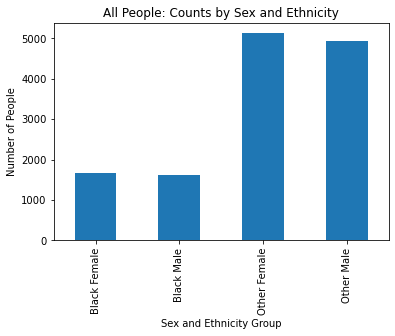

In [77]:
# counts by group - all
print(all_data['group'].value_counts().sort_index())
all_data['group'].value_counts().sort_index().plot(kind = 'bar')

plt.title('All People: Counts by Sex and Ethnicity')
plt.xlabel('Sex and Ethnicity Group')
plt.ylabel('Number of People')

Black Female     562
Black Male       595
Other Female    1388
Other Male      1574
Name: group, dtype: int64


Text(0, 0.5, 'Number of People')

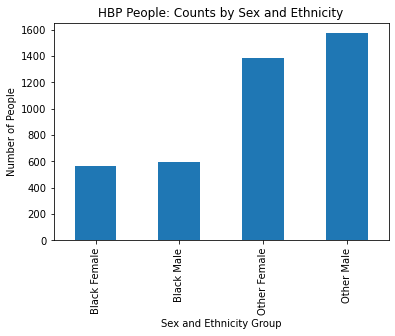

In [78]:
# counts by group - hbp
print(hbp_data['group'].value_counts().sort_index())
hbp_data['group'].value_counts().sort_index().plot(kind = 'bar')

plt.title('HBP People: Counts by Sex and Ethnicity')
plt.xlabel('Sex and Ethnicity Group')
plt.ylabel('Number of People')

In [79]:
# faceted plot of counts on same scale
count_breakdown = all_data.groupby(by=['sex', 'ethnicity_binary', 'has_hbp']).size().reset_index(name = 'count')
count_breakdown

,sex,ethnicity_binary,has_hbp,count
0,Female,Black,0,1107
1,Female,Black,1,562
2,Female,Other,0,3739
3,Female,Other,1,1388
4,Male,Black,0,1010
5,Male,Black,1,595
6,Male,Other,0,3363
7,Male,Other,1,1574


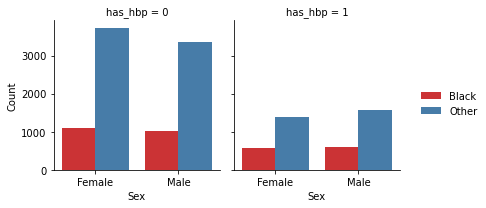

In [80]:
# faceted plot of counts on same scale
plot = sns.FacetGrid(count_breakdown, col='has_hbp', margin_titles = True)
plot.map_dataframe(sns.barplot, x='sex', y='count', hue='ethnicity_binary', palette='Set1')
plot.set_axis_labels('Sex', 'Count')
plot.add_legend()

In [81]:
# faceted plot of statin recommendation counts - all
count_breakdown_all_rec = all_data.groupby(by=['sex', 'ethnicity_binary', 'g1_is_rec']).size().reset_index(name = 'count')
count_breakdown_all_rec

,sex,ethnicity_binary,g1_is_rec,count
0,Female,Black,0,898
1,Female,Black,1,771
2,Female,Other,0,3494
3,Female,Other,1,1633
4,Male,Black,0,386
5,Male,Black,1,1219
6,Male,Other,0,1993
7,Male,Other,1,2944


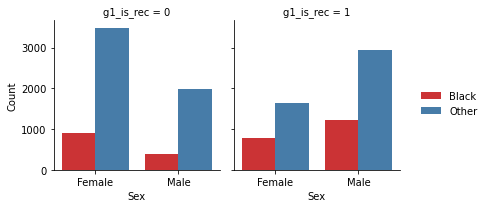

In [82]:
# faceted plot of statin recommendation counts - all
plot = sns.FacetGrid(count_breakdown_all_rec, col='g1_is_rec', margin_titles = True)
plot.map_dataframe(sns.barplot, x='sex', y='count', hue='ethnicity_binary', palette='Set1')
plot.set_axis_labels('Sex', 'Count')
plot.add_legend()

In [83]:
# faceted plot of statin recommendation counts - hbp
count_breakdown_hbp_rec = hbp_data.groupby(by=['sex', 'ethnicity_binary', 'g2_is_rec']).size().reset_index(name = 'count')
count_breakdown_hbp_rec

,sex,ethnicity_binary,g2_is_rec,count
0,Female,Black,0,323
1,Female,Black,1,239
2,Female,Other,0,990
3,Female,Other,1,398
4,Male,Black,0,191
5,Male,Black,1,404
6,Male,Other,0,771
7,Male,Other,1,803


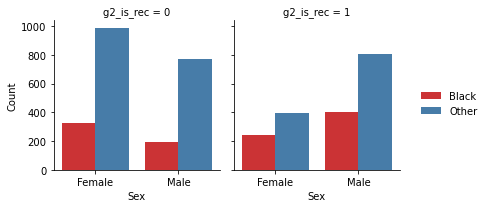

In [84]:
# faceted plot of statin recommendation counts - hbp
plot = sns.FacetGrid(count_breakdown_hbp_rec, col='g2_is_rec', margin_titles = True)
plot.map_dataframe(sns.barplot, x='sex', y='count', hue='ethnicity_binary', palette='Set1')
plot.set_axis_labels('Sex', 'Count')
plot.add_legend()

In [96]:
table_data = all_data

# change labels for recommendation 
table_data['g1_is_rec'] = np.where(table_data['g1_is_rec'] == '0', 'No', 'Yes')

# delete unnecessary columns
cols = table_data.columns.to_list()
indices = [16, 15, 13, 12, 0]

for index in indices:
    del cols[index]

# variables for table 1 creation
cat_vars = ['has_hype_med', 'sex', 'ethnicity', 'is_diabetic', 'does_smoke', 'has_hbp']
outcome_var = ['g1_is_rec']
labels = {'high_chol':'high cholesterol',
          'total_chol':'total cholesterol',
          'has_hype_med':'is taking hypertension medication',
          'is_diabetic':'is diabetic',
          'does_smoke':'does smoke',
          'has_hbp':'has high blood pressure',
          'g1_is_rec':'Statin Recommendation'}

mytable = TableOne(table_data, 
                   columns = cols, 
                   categorical = cat_vars, 
                   rename = labels, 
                   groupby = outcome_var)
mytable

Grouped by Statin Recommendation                                          
                                                                                     Missing       Overall            No           Yes
n                                                                                                    13338          6771          6567
age, mean (SD)                                                                             0   57.5 (10.6)    50.5 (7.3)    64.8 (8.4)
high cholesterol, mean (SD)                                                                0   53.6 (16.7)   55.9 (16.8)   51.2 (16.3)
total cholesterol, mean (SD)                                                               0  194.6 (42.7)  196.7 (38.4)  192.4 (46.6)
is taking hypertension medication, n (%) 0                                                 0   7596 (57.0)   5057 (74.7)   2539 (38.7)
                                         1                                                     5742 (43.0)   1714 (25.3)   4028 (61.3)
sex, n (%)                               Female                                            0   6796 (51.0)   4392 (64.9)   2404 (36.6)
                                         Male                                                  6542 (49.0)   2379 (35.1)   4163 (63.4)
ethnicity, n (%)                         Mexican American                                  0   1728 (13.0)    985 (14.5)    743 (11.3)
                                         Non-Hispanic Asian                                    1584 (11.9)   1008 (14.9)     576 (8.8)
                                         Non-Hispanic Black                                    3274 (24.5)   1284 (19.0)   1990 (30.3)
                                         Non-Hispanic White                                    4829 (36.2)   2484 (36.7)   2345 (35.7)
                                         Other Hispanic                                        1508 (11.3)    792 (11.7)    716 (10.9)
                                         Other Race                                              415 (3.1)     218 (3.2)     197 (3.0)
is diabetic, n (%)                       0                                                 0  10773 (80.8)   6263 (92.5)   4510 (68.7)
                                         1                                                     2565 (19.2)     508 (7.5)   2057 (31.3)
does smoke, n (%)                        0                                                 0  10793 (80.9)   5892 (87.0)   4901 (74.6)
                                         1                                                     2545 (19.1)    879 (13.0)   1666 (25.4)
sbp, mean (SD)                                                                             0  127.6 (18.3)  120.4 (14.4)  135.0 (19.0)
dbp, mean (SD)                                                                             0   73.2 (12.4)   73.7 (10.7)   72.7 (14.0)
has high blood pressure, n (%)           0                                                 0   9219 (69.1)   4919 (72.6)   4300 (65.5)
                                         1                                                     4119 (30.9)   1852 (27.4)   2267 (34.5)

In [1]:
##################################################
##########
##########
########## Visualization/Analysis
##########
##########
##################################################

In [3]:
# package import
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LogisticRegression
import numpy as np
import math

# read files
all_data = pd.read_csv('/Users/mtjen/Desktop/schiltz24/nhanes_project/interview/all_statin_rec.csv')
hbp_data = pd.read_csv('/Users/mtjen/Desktop/schiltz24/nhanes_project/interview/hbp_statin_rec.csv')

all_data = all_data.drop('Unnamed: 0', axis = 1)
hbp_data = hbp_data.drop('Unnamed: 0', axis = 1)

all_data['has_hype_med'] = all_data['has_hype_med'].astype(str)
all_data['is_diabetic'] = all_data['is_diabetic'].astype(str)
all_data['does_smoke'] = all_data['does_smoke'].astype(str)
all_data['has_hbp'] = all_data['has_hbp'].astype(str)
all_data['g1_is_rec'] = all_data['g1_is_rec'].astype(str)
all_data['g2_is_rec'] = all_data['g2_is_rec'].astype(str)

hbp_data['has_hype_med'] = hbp_data['has_hype_med'].astype(str)
hbp_data['is_diabetic'] = hbp_data['is_diabetic'].astype(str)
hbp_data['does_smoke'] = hbp_data['does_smoke'].astype(str)
hbp_data['has_hbp'] = hbp_data['has_hbp'].astype(str)
hbp_data['g1_is_rec'] = hbp_data['g1_is_rec'].astype(str)
hbp_data['g2_is_rec'] = hbp_data['g2_is_rec'].astype(str)

In [18]:
# create plots of recommendation percentages
def create_rec_perc_plot(data, group_string, is_hbp):
    # subset data
    data_subset = data[data['group'] == group_string]
    
    # get recommendation percentages by age
    if is_hbp == 0:
        group_data = data_subset.groupby(['age'])['g1_is_rec'].value_counts(normalize=True).reset_index(name='proportion')
        rec_data = group_data[group_data['g1_is_rec'] == '1']
        rec_data = rec_data.drop('g1_is_rec', axis = 1)
    else:
        group_data = data_subset.groupby(['age'])['g2_is_rec'].value_counts(normalize=True).reset_index(name='proportion')
        rec_data = group_data[group_data['g2_is_rec'] == '1']
        rec_data = rec_data.drop('g2_is_rec', axis = 1)
        
    rec_data = rec_data.reset_index().drop('index', axis = 1)
    
    # create plot
    plt.bar(rec_data['age'], rec_data['proportion'])
    plt.axhline(y = 0.5, color = 'red', linestyle = '--')
    plt.axhline(y = 1.0, color = 'red', linestyle = '--')
    plt.title('Statin Recommendation Proportion by Age: {}'.format(group_string))
    plt.xlabel('Age')
    plt.ylabel('Proportion Recommended to Take Statin')

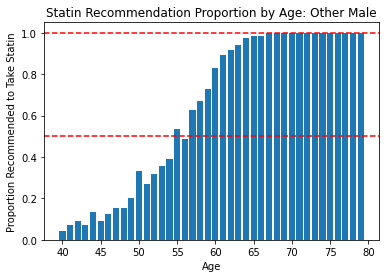

In [20]:
create_rec_perc_plot(all_data, "Other Male", 0)

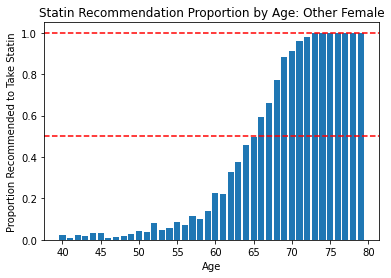

In [21]:
create_rec_perc_plot(all_data, "Other Female", 0)

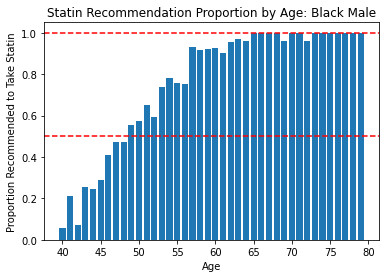

In [22]:
create_rec_perc_plot(all_data, "Black Male", 0)

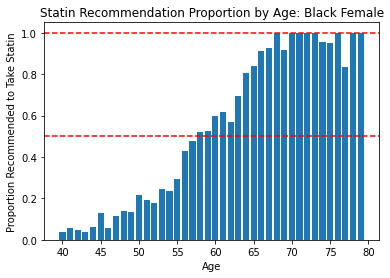

In [23]:
create_rec_perc_plot(all_data, "Black Female", 0)

In [3]:
# get odds ratios for all data 

# create dummy variables
all_data['is_female'] = np.where(all_data['sex'] == 'Female', 1, 0)
all_data['is_black'] = np.where(all_data['ethnicity_binary'] == 'Black', 1, 0)

# create datasets
x_data = all_data[['age', 'high_chol', 'total_chol', 'has_hype_med', 'is_female',
                   'is_black', 'is_diabetic', 'does_smoke', 'sbp','dbp']]
y_data = all_data['g1_is_rec']

x_data.apply(pd.to_numeric)
y_data.apply(pd.to_numeric)


param_est = LogisticRegression().fit(x_data, y_data).coef_[0]
odds_ratios = []

for est in param_est:
    odds_ratios.append(math.exp(est))

cols = x_data.columns.tolist()
res = pd.DataFrame(cols)
res.columns = ['variable']
res['estimates'] = param_est
res['odds_ratio'] = odds_ratios
res

/Users/mtjen/opt/anaconda3/lib/python3.8/site-packages/sklearn/linear_model/_logistic.py:814: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


,variable,estimates,odds_ratio
0,age,0.455966,1.577697
1,high_chol,-0.078431,0.924566
2,total_chol,0.027603,1.027988
3,has_hype_med,2.446695,11.550113
4,is_female,-3.647265,0.026062
5,is_black,2.283844,9.814331
6,is_diabetic,6.153700,470.454639
7,does_smoke,3.815766,45.411514
8,sbp,0.081686,1.085115
9,dbp,-0.010388,0.989665


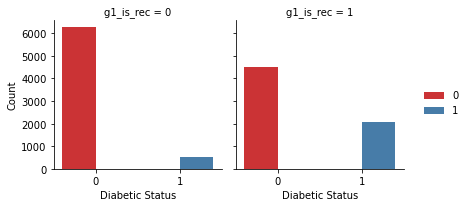

In [9]:
# counts by group - all
test = all_data

# faceted plot of statin recommendation counts - hbp
count_breakdown_test = test.groupby(by=['is_diabetic', 'g1_is_rec']).size().reset_index(name = 'count')

plot = sns.FacetGrid(count_breakdown_test, col='g1_is_rec', margin_titles = True)
plot.map_dataframe(sns.barplot, x='is_diabetic', y='count', hue='is_diabetic', palette='Set1')
plot.set_axis_labels('Diabetic Status', 'Count')
plot.add_legend()

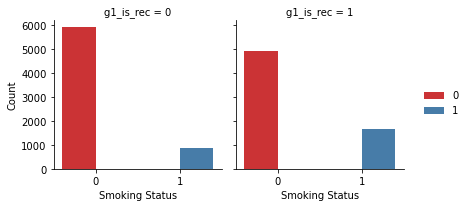

In [10]:
# counts by group - all
test = all_data

# faceted plot of statin recommendation counts - hbp
count_breakdown_test = test.groupby(by=['does_smoke', 'g1_is_rec']).size().reset_index(name = 'count')

plot = sns.FacetGrid(count_breakdown_test, col='g1_is_rec', margin_titles = True)
plot.map_dataframe(sns.barplot, x='does_smoke', y='count', hue='does_smoke', palette='Set1')
plot.set_axis_labels('Smoking Status', 'Count')
plot.add_legend()

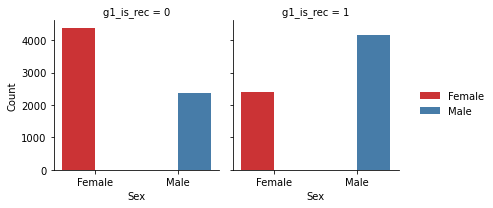

In [13]:
# counts by group - all
test = all_data
test['sex'] = np.where(test['is_female'] == 0, 'Male', 'Female')

# faceted plot of statin recommendation counts - hbp
count_breakdown_test = test.groupby(by=['sex', 'g1_is_rec']).size().reset_index(name = 'count')

plot = sns.FacetGrid(count_breakdown_test, col='g1_is_rec', margin_titles = True)
plot.map_dataframe(sns.barplot, x='sex', y='count', hue='sex', palette='Set1')
plot.set_axis_labels('Sex', 'Count')
plot.add_legend()

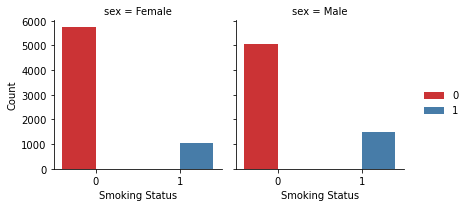

In [9]:
# counts by group - all
test = all_data
test['sex'] = np.where(test['is_female'] == 0, 'Male', 'Female')

# faceted plot of statin recommendation counts - hbp
count_breakdown_test = test.groupby(by=['sex', 'does_smoke']).size().reset_index(name = 'count')

plot = sns.FacetGrid(count_breakdown_test, col='sex', margin_titles = True)
plot.map_dataframe(sns.barplot, x='does_smoke', y='count', hue='does_smoke', palette='Set1')
plot.set_axis_labels('Smoking Status', 'Count')
plot.add_legend()

In [5]:
count_breakdown_test

,is_female,does_smoke,g1_is_rec,count
0,0,0,0,2057
1,0,0,1,3005
2,0,1,0,322
3,0,1,1,1158
4,1,0,0,3835
5,1,0,1,1896
6,1,1,0,557
7,1,1,1,508


In [28]:
# get odds ratios for hbp data 

# create dummy variables
hbp_data['is_female'] = np.where(hbp_data['sex'] == 'Female', 1, 0)
hbp_data['is_black'] = np.where(hbp_data['ethnicity_binary'] == 'Black', 1, 0)


# create datasets
x_data = hbp_data[['age', 'high_chol', 'total_chol', 'has_hype_med', 'is_female',
                   'is_black', 'is_diabetic', 'does_smoke', 'sbp','dbp']]
y_data = hbp_data['g1_is_rec']

x_data.apply(pd.to_numeric)
y_data.apply(pd.to_numeric)


param_est = LogisticRegression().fit(x_data, y_data).coef_[0]
odds_ratios = []

for est in param_est:
    odds_ratios.append(math.exp(est))

cols = x_data.columns.tolist()
res = pd.DataFrame(cols)
res.columns = ['variable']
res['estimates'] = param_est
res['odds_ratio'] = odds_ratios
res

/Users/mtjen/opt/anaconda3/lib/python3.8/site-packages/sklearn/linear_model/_logistic.py:814: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


,variable,estimates,odds_ratio
0,age,0.280848,1.324253
1,high_chol,-0.072359,0.930197
2,total_chol,0.006521,1.006542
3,has_hype_med,1.430246,4.179726
4,is_female,-2.564924,0.076925
5,is_black,1.553279,4.726945
6,is_diabetic,2.502132,12.208496
7,does_smoke,2.995653,19.998410
8,sbp,-0.006304,0.993716
9,dbp,-0.133272,0.875227


In [1]:
##################################################
##########
##########
########## Shapley
##########
##########
##################################################

In [9]:
# package import
import pandas as pd
import numpy as np

import xgboost
import shap

# read files
all_data = pd.read_csv('/Users/mtjen/Desktop/schiltz24/nhanes_project/interview/all_statin_rec.csv')
hbp_data = pd.read_csv('/Users/mtjen/Desktop/schiltz24/nhanes_project/interview/hbp_statin_rec.csv')

all_data = all_data.drop('Unnamed: 0', axis = 1)
hbp_data = hbp_data.drop('Unnamed: 0', axis = 1)

print(all_data.shape)
print(hbp_data.shape)


all_data['has_hype_med'] = all_data['has_hype_med'].astype(str)
all_data['is_diabetic'] = all_data['is_diabetic'].astype(str)
all_data['does_smoke'] = all_data['does_smoke'].astype(str)
all_data['has_hbp'] = all_data['has_hbp'].astype(str)
all_data['g1_is_rec'] = all_data['g1_is_rec'].astype(str)
all_data['g2_is_rec'] = all_data['g2_is_rec'].astype(str)

hbp_data['has_hype_med'] = hbp_data['has_hype_med'].astype(str)
hbp_data['is_diabetic'] = hbp_data['is_diabetic'].astype(str)
hbp_data['does_smoke'] = hbp_data['does_smoke'].astype(str)
hbp_data['has_hbp'] = hbp_data['has_hbp'].astype(str)
hbp_data['g1_is_rec'] = hbp_data['g1_is_rec'].astype(str)
hbp_data['g2_is_rec'] = hbp_data['g2_is_rec'].astype(str)

print(all_data.dtypes)

(13338, 17)
(4119, 17)
SEQN                  int64
age                   int64
high_chol             int64
total_chol            int64
has_hype_med         object
sex                  object
ethnicity            object
is_diabetic          object
does_smoke           object
sbp                 float64
dbp                 float64
has_hbp              object
ethnicity_binary     object
risk_score          float64
g1_is_rec            object
g2_is_rec            object
group                object
dtype: object


In [10]:
# create dummy variables
all_data['is_female'] = np.where(all_data['sex'] == 'Female', 1, 0)
all_data['is_black'] = np.where(all_data['ethnicity_binary'] == 'Black', 1, 0)

# create datasets
x_data = all_data[['age', 'high_chol', 'total_chol', 'has_hype_med', 'is_female',
                   'is_black', 'is_diabetic', 'does_smoke', 'sbp','dbp']]
y_data = all_data['g1_is_rec']

x_data = x_data.apply(pd.to_numeric)
y_data = y_data.apply(pd.to_numeric)

x_data.head()

,age,high_chol,total_chol,has_hype_med,is_female,is_black,is_diabetic,does_smoke,sbp,dbp
0,44,28,190,0,1,0,0,0,118.000000,60.000000
1,43,73,169,0,1,1,0,1,102.000000,71.333333
2,51,43,198,0,0,0,0,1,146.666667,70.000000
3,55,54,206,0,0,0,0,0,124.666667,76.000000
4,70,35,118,0,0,1,0,0,158.666667,62.666667


In [6]:
x_data.dtypes

age               int64
high_chol         int64
total_chol        int64
has_hype_med      int64
is_female         int64
is_black          int64
is_diabetic       int64
does_smoke        int64
sbp             float64
dbp             float64
dtype: object

In [28]:
# by s+g
def create_shap_plot(data, group_string):
    # subset data
    data_subset = data[data['group'] == group_string]
    
    # create dummy variables
    data_subset['is_female'] = np.where(data_subset['sex'] == 'Female', 1, 0)
    data_subset['is_black'] = np.where(data_subset['ethnicity_binary'] == 'Black', 1, 0)

    # create datasets
    x_data = data_subset[['age', 'high_chol', 'total_chol', 'has_hype_med', 
                          'is_diabetic', 'does_smoke', 'sbp','dbp']]
    y_data = data_subset['g1_is_rec']

    x_data = x_data.apply(pd.to_numeric)
    y_data = y_data.apply(pd.to_numeric)

    # XGboost model
    mod = xgboost.XGBRegressor().fit(x_data, y_data)

    # get shapley values
    explainer = shap.Explainer(mod)
    shap_values = explainer(x_data)

    # visualize
    shap.plots.beeswarm(shap_values)


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy


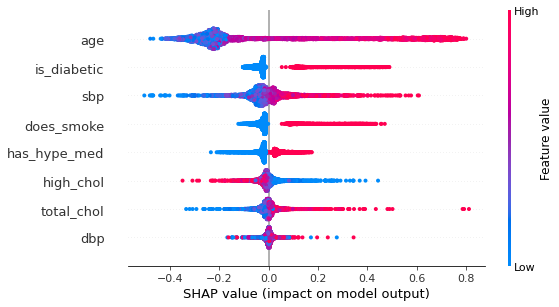

In [29]:
create_shap_plot(all_data, 'Other Female')


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy


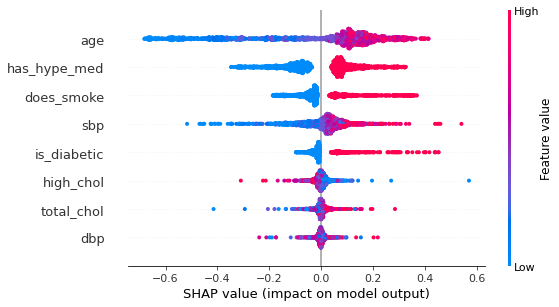

In [31]:
create_shap_plot(all_data, 'Black Male')

In [20]:
# overall shapley

# create dummy variables
all_data['is_female'] = np.where(all_data['sex'] == 'Female', 1, 0)
all_data['is_black'] = np.where(all_data['ethnicity_binary'] == 'Black', 1, 0)

# create datasets
x_data = all_data[['age', 'high_chol', 'total_chol', 'has_hype_med', 'is_female',
                   'is_black', 'is_diabetic', 'does_smoke', 'sbp','dbp']]
y_data = all_data['g1_is_rec']

x_data = x_data.apply(pd.to_numeric)
y_data = y_data.apply(pd.to_numeric)


# XGboost model
mod = xgboost.XGBRegressor().fit(x_data, y_data)

# get shapley values
explainer = shap.Explainer(mod)
shap_values = explainer(x_data)

In [21]:
pd.DataFrame(all_data.loc[0])

,0
SEQN,62164
age,44
high_chol,28
total_chol,190
has_hype_med,0
sex,Female
ethnicity,Non-Hispanic White
is_diabetic,0
does_smoke,0
sbp,118.0


In [22]:
shap.plots.initjs()
shap.plots.force(shap_values[0])

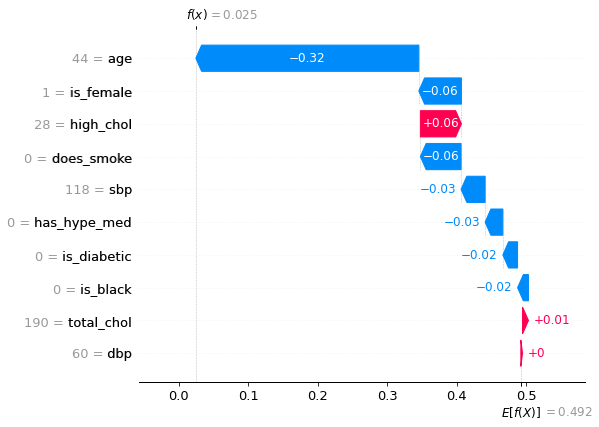

In [23]:
shap.plots.waterfall(shap_values[0])

In [24]:
pd.DataFrame(all_data.loc[4])

,4
SEQN,62191
age,70
high_chol,35
total_chol,118
has_hype_med,0
sex,Male
ethnicity,Non-Hispanic Black
is_diabetic,0
does_smoke,0
sbp,158.666667


In [25]:
shap.plots.initjs()
shap.plots.force(shap_values[4])

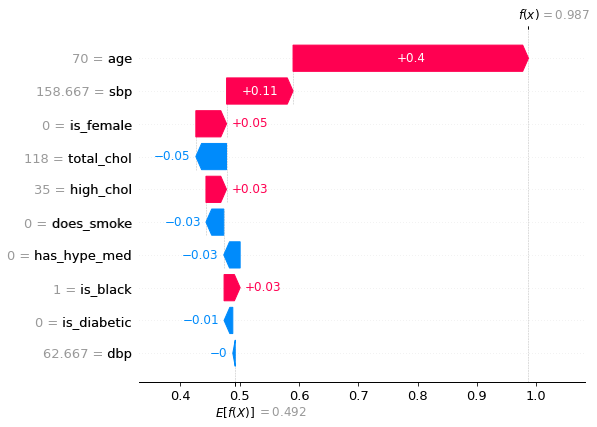

In [26]:
shap.plots.waterfall(shap_values[4])

In [ ]:
# can't create same styles of force plots for all observations due to limitations of Python SHAP package